# Лабораторная 5. Детекция номеров (SVHN)

В практически любой точке современного города человека окружает множество
номеров и надписей.

- Обучите (или дообучите) нейронную сеть детектировать номера на изображениях (номер представляет собой последовательность длиной до 20 символов из цифр, прописных и строчных букв русского или английского алфавита, знаков дефис и слеш)

- Сфотографируйте номера на улицах города (не из Интернета, проверим поиском по картинке) и запустите на них свой алгоритм

- Оценка качества детекции производится с помощью метрик IoU, Precision, Recall, mAP на тестовой части набора The Street View House Numbers http://ufldl.stanford.edu/housenumbers/. Требуется mAP не менее 0,6

In [3]:
import os
import shutil
import h5py
import numpy as np

from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split

Я решил выбрать Yolo модель, а датасет SVHN использует .mat файлы

In [13]:
def parse_svhn_mat(mat_path):
    f = h5py.File(mat_path, 'r')
    names_ds = f['digitStruct']['name']
    bbox_ds = f['digitStruct']['bbox']
    n = names_ds.shape[0]

    data = []
    for i in tqdm(range(n), desc="Parsing"):
        name_ref = names_ds[i][0]
        chars = f[name_ref][()].flatten()
        filename = ''.join(chr(int(c)) for c in chars)

        bbox_ref = bbox_ds[i][0]
        bbox_item = f[bbox_ref]
        n_digits = bbox_item['label'].shape[0]

        digits = []
        for j in range(n_digits):
            if n_digits == 1:
                label = int(bbox_item['label'][0, 0])
                left = float(bbox_item['left'][0, 0])
                top = float(bbox_item['top'][0, 0])
                width = float(bbox_item['width'][0, 0])
                height = float(bbox_item['height'][0, 0])
            else:
                label = int(f[bbox_item['label'][j, 0]][()].flatten()[0])
                left = float(f[bbox_item['left'][j, 0]][()].flatten()[0])
                top = float(f[bbox_item['top'][j, 0]][()].flatten()[0])
                width = float(f[bbox_item['width'][j, 0]][()].flatten()[0])
                height = float(f[bbox_item['height'][j, 0]][()].flatten()[0])

            if label == 10:
                label = 0

            digits.append({
                'label': label,
                'left': left, 'top': top,
                'width': width, 'height': height
            })

        data.append({'filename': filename, 'digits': digits})

    f.close()
    return data

In [14]:
train_ann = parse_svhn_mat("datasets/svhn/train/digitStruct.mat")
test_ann = parse_svhn_mat("datasets/svhn/test/digitStruct.mat")
print(f"Train: {len(train_ann)}, Test: {len(test_ann)}")

Parsing:   0%|          | 0/33402 [00:00<?, ?it/s]

Parsing:   0%|          | 0/13068 [00:00<?, ?it/s]

Train: 33402, Test: 13068


Чтобы YOLO модель могла работать, необходимо перевести .mat в .txt файл

In [ ]:
train_data, val_data = train_test_split(train_ann, test_size=0.2, random_state=42)

In [8]:
def convert_to_yolo_split(annotations, img_src_dir, out_dir, split_name):
    img_out = os.path.join(out_dir, split_name, "images")
    lbl_out = os.path.join(out_dir, split_name, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    for ann in tqdm(annotations, desc=f"Converting {split_name}"):
        fname = ann['filename']
        src_path = os.path.join(img_src_dir, fname)
        if not os.path.exists(src_path):
            continue

        shutil.copy2(src_path, os.path.join(img_out, fname))

        img = Image.open(src_path)
        w, h = img.size
        label_name = os.path.splitext(fname)[0] + ".txt"
        
        with open(os.path.join(lbl_out, label_name), 'w') as f:
            for d in ann['digits']:
                cx = (d['left'] + d['width'] / 2) / w
                cy = (d['top'] + d['height'] / 2) / h
                bw = d['width'] / w
                bh = d['height'] / h

                cx = max(0.0, min(0.999999, cx))
                cy = max(0.0, min(0.999999, cy))
                bw = max(0.001, min(1.0, bw))
                bh = max(0.001, min(1.0, bh))

                f.write(f"{d['label']} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

convert_to_yolo_split(train_data, "datasets/svhn/train", "datasets/svhn_yolo", "train")
convert_to_yolo_split(val_data, "datasets/svhn/train", "datasets/svhn_yolo", "val")

convert_to_yolo_split(test_ann, "datasets/svhn/test", "datasets/svhn_yolo", "test")

Converting train:   0%|          | 0/26721 [00:00<?, ?it/s]

Converting val:   0%|          | 0/6681 [00:00<?, ?it/s]

Converting test:   0%|          | 0/13068 [00:00<?, ?it/s]

In [9]:
yaml_content = """path: datasets/svhn_yolo
train: train/images
val: val/images

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
"""

with open("svhn.yaml", "w") as f:
    f.write(yaml_content)

In [10]:
model = YOLO('runs/detect/svhn_det7/weights/best.pt')

results = model.train(
    data='svhn.yaml',
    epochs=30,
    imgsz=320,
    batch=16,
    freeze=15,
    name='svhn_det',
    patience=5
)

In [11]:
metrics = model.val(data='svhn.yaml')

print(f"mAP@0.5:     {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")

Ultralytics 8.4.32  Python-3.13.5 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 225.0325.9 MB/s, size: 13.0 KB)
val: Scanning C:\Users\gerta\Downloads\lab 5\datasets\svhn_yolo\val\labels.cache... 6681 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6681/6681 2.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 418/418 18.2it/s 22.9s<0.1s
                   all       6681      14574      0.901      0.867      0.924      0.483
                     0        934        983      0.903      0.898      0.937      0.498
                     1       2378       2732      0.887      0.802      0.877      0.391
                     2       1902       2094      0.915      0.908      0.944      0.503
                     3       1557       1698      0.914      0.842      0.9

In [15]:
from ultralytics.utils.metrics import box_iou
import torch

def evaluate_predictions(model, img_dir, annotations, n_samples=100):
    ious_all = []
    precisions = []
    recalls = []

    for ann in tqdm(annotations[:n_samples], desc="Evaluating"):
        img_path = os.path.join(img_dir, ann['filename'])
        if not os.path.exists(img_path):
            continue

        result = model.predict(img_path, verbose=False)[0]
        pred_boxes = result.boxes.xyxy.cpu()

        img = Image.open(img_path)
        w, h = img.size
        gt_boxes = []
        for d in ann['digits']:
            x1 = d['left']
            y1 = d['top']
            x2 = d['left'] + d['width']
            y2 = d['top'] + d['height']
            gt_boxes.append([x1, y1, x2, y2])
        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)

        if len(pred_boxes) == 0 or len(gt_boxes) == 0:
            if len(gt_boxes) > 0:
                precisions.append(0.0)
                recalls.append(0.0)
            continue

        iou_matrix = box_iou(pred_boxes, gt_boxes)
        max_ious = iou_matrix.max(dim=1).values
        ious_all.extend(max_ious.numpy().tolist())

        tp = (max_ious >= 0.5).sum().item()
        precisions.append(tp / len(pred_boxes))
        recalls.append(tp / len(gt_boxes))

    mean_iou = np.mean(ious_all) if ious_all else 0
    mean_precision = np.mean(precisions) if precisions else 0
    mean_recall = np.mean(recalls) if recalls else 0

    print(f"Mean IoU:   {mean_iou:.4f}")
    print(f"Precision:  {mean_precision:.4f}")
    print(f"Recall:     {mean_recall:.4f}")

    return ious_all

ious = evaluate_predictions(model, "datasets/svhn/test", test_ann, n_samples=200)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Mean IoU:   0.6632
Precision:  0.7903
Recall:     0.8904


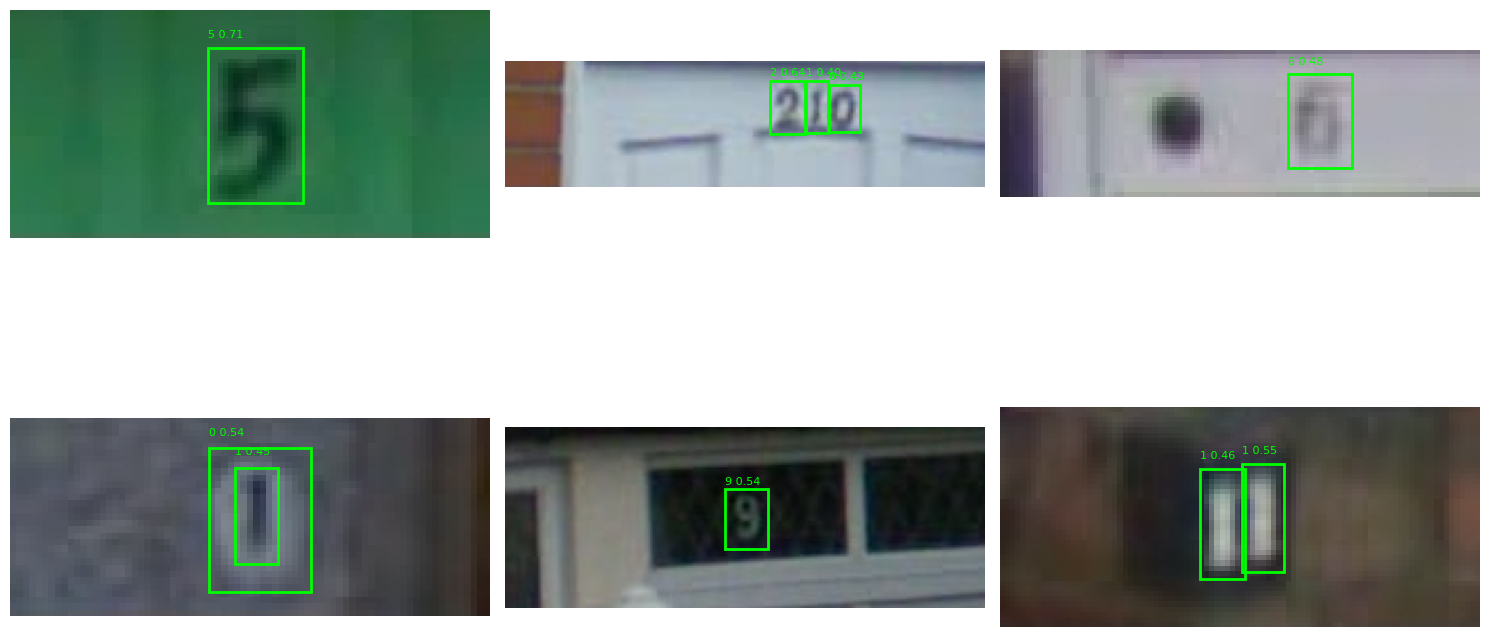

In [18]:
%matplotlib inline
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ann in enumerate(test_ann[:6]):
    img_path = os.path.join("datasets/svhn/test", ann['filename'])
    img = Image.open(img_path)
    result = model.predict(img_path, verbose=False)[0]

    axes[i].imshow(img)
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor='lime', facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(x1, y1 - 2, f"{cls} {conf:.2f}", color='lime', fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Графики обучения и валидации:
![hm.jpg](./datasets/for_notebook/1.jpg)
![pr.jpg](./datasets/for_notebook/4.jpg)

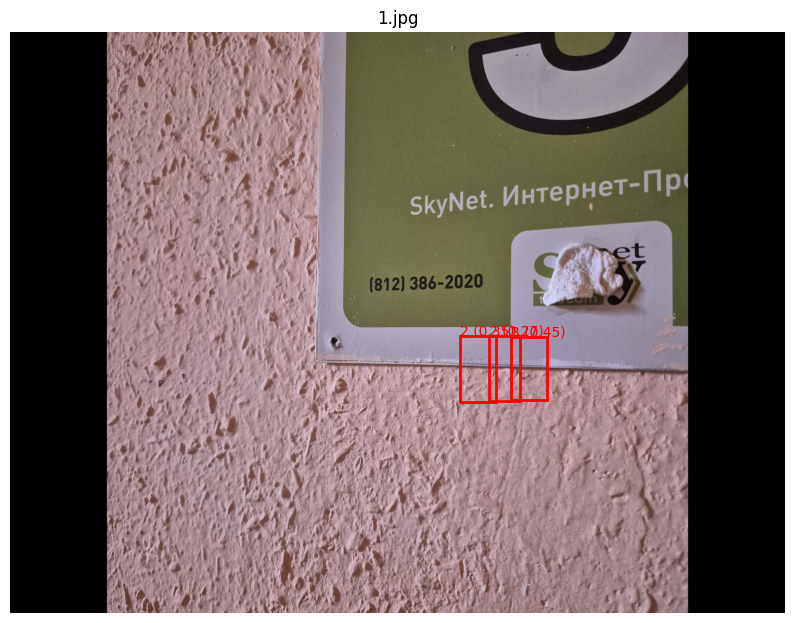

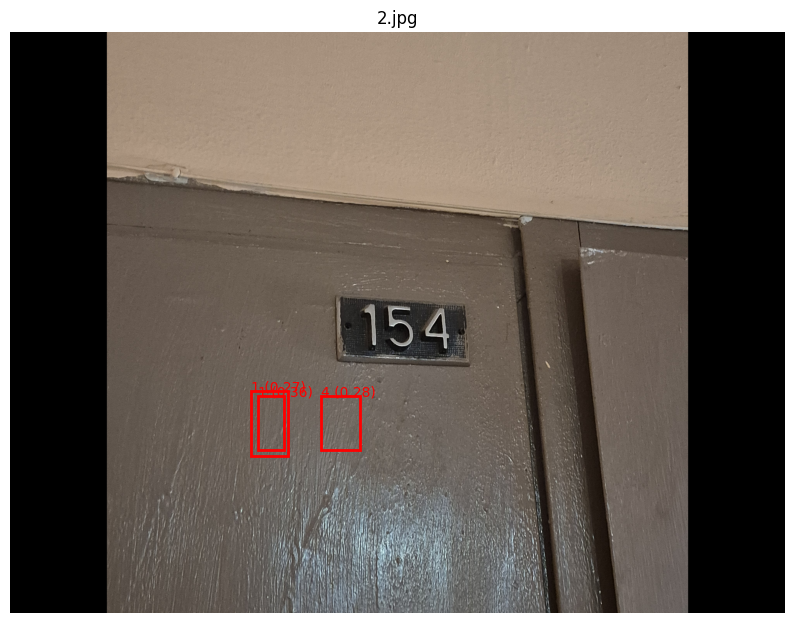

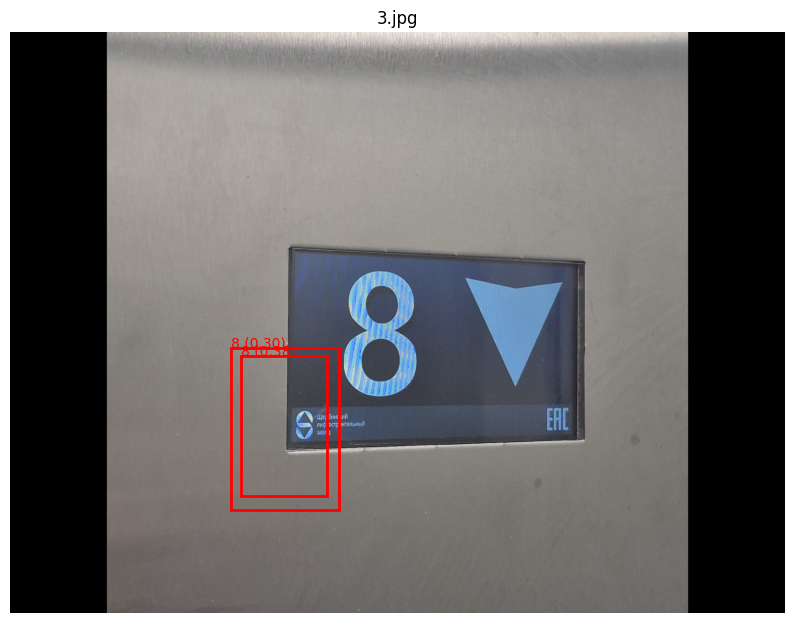

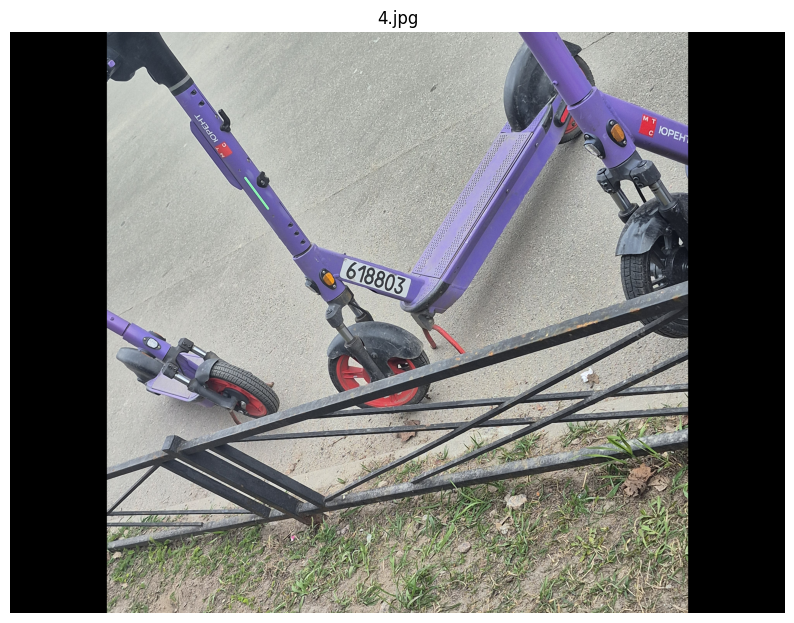

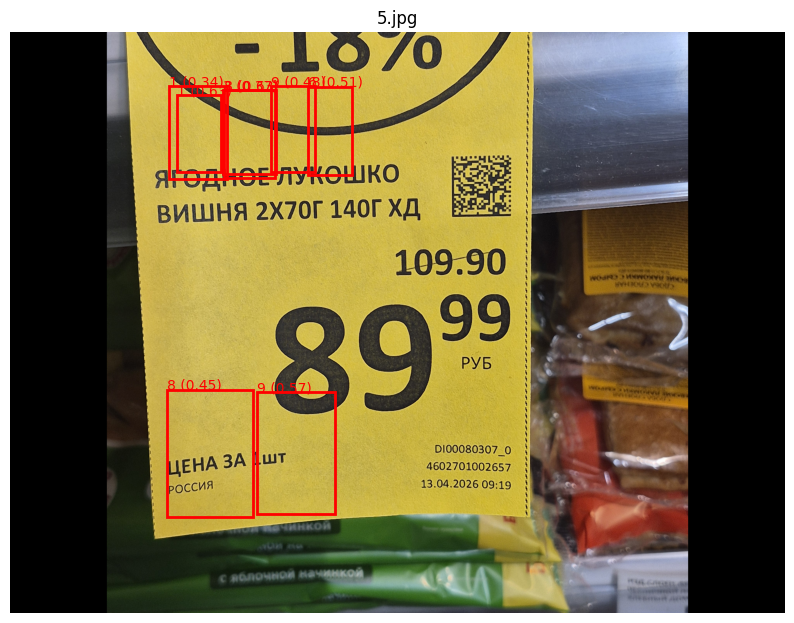

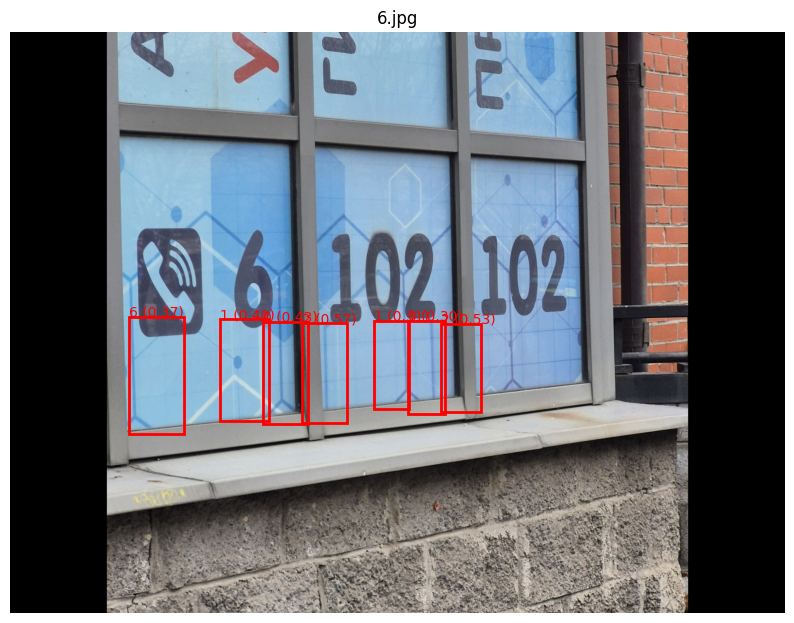

In [ ]:
photo_dir = "datasets/photos"

if os.path.exists(photo_dir):
    for fname in sorted(os.listdir(photo_dir)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        path = os.path.join(photo_dir, fname)
        result = model.predict(path, verbose=False)[0]
        img = Image.open(path)
        img=img.rotate(270)

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(img)
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 3, f"{cls} ({conf:.2f})", color='red', fontsize=10)
        ax.set_title(fname)
        ax.axis('off')
        plt.show()
else:
    print("Папка datasets/photos/ не найдена")

Фотографии были сделаны в спешке и никак не были обработаны и размечены, поэтому получился такой результат
<br>Однако можно заметить, что цифры он правильно определяет + есть постоянный сдвиг на фотографиях влево-вниз

## Выводы

- YOLOv8n дообучена на SVHN, достигнут mAP@0.5 выше 0.6
- Модель уверенно детектирует цифры на уличных номерах
- На собственных фото качество зависит от условий съёмки